<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/ResNet34_UKAN_REFUGE_3class_tta_postprocess_week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet34-U-KAN — 3-Class Optic Disc & Cup Segmentation (REFUGE)

Pretrained **ResNet34 encoder** → **KAN bottleneck** (3 KANLinear sublayers) → **U-Net decoder**.

Baked in:
- **Two learning rates** — conv/encoder at a low LR (protects ImageNet weights), KAN spline layers 100x higher
- **Pretrained ResNet34** encoder (ImageNet) — the biggest lever for 400-image REFUGE
- **Loss = CrossEntropy + Dice** (equal class weights — the recipe that reached 0.90; Focal-Tversky off by default)
- Full metrics (Dice/IoU/Precision/Recall/F1/Acc + HD95) with 6-panel curves
- **TTA** + anatomical **post-processing**, qualitative Input/GT/Raw/Post panels




In [ ]:
# ================= CELL 1 — Setup, imports & configuration =================
import os, sys, glob, math, random, time, warnings, json
warnings.filterwarnings("ignore")
import numpy as np, cv2, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    os.system("pip install -q albumentations"); import albumentations as A
    from albumentations.pytorch import ToTensorV2
from scipy import ndimage

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch",torch.__version__,"| device:",DEVICE,
      "|",torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

class CFG:
    # data / model
    IMG_SIZE=384; NUM_CLASSES=3
    PRETRAINED=True            # ImageNet-pretrained ResNet34 encoder
    KAN_DEPTH=1                # number of KAN blocks in the bottleneck
    # training
    BATCH_SIZE=8; ACCUM_STEPS=2; EPOCHS=120; PATIENCE=25
    NUM_WORKERS=2; USE_AMP=True
    # --- two learning rates ---
    BASE_LR=1e-4               # conv encoder + decoder (low: protects pretrained weights)
    KAN_LR=1e-2                # KAN spline layers fc1/fc2/fc3 (100x higher: splines start as noise)
    WEIGHT_DECAY=1e-4; KAN_WEIGHT_DECAY=1e-4; MIN_LR=1e-5
    # loss = W_CE*CE + W_DICE*Dice + W_FT*FocalTversky
    W_CE=0.5; W_DICE=0.5; W_FT=0.0          # FT off by default (it over-corrected the cup before)
    CLASS_WEIGHTS=[1.0,1.0,1.0]
    TVERSKY_ALPHA=0.4; TVERSKY_BETA=0.6; TVERSKY_GAMMA=0.75
    # inference
    USE_TTA=True; USE_POSTPROC=True
    OUT_DIR="/content/outputs"; CKPT_PATH="/content/outputs/resnet34_ukan_best.pth"
cfg=CFG(); os.makedirs(cfg.OUT_DIR,exist_ok=True)
print(f"IMG_SIZE={cfg.IMG_SIZE} | eff.batch={cfg.BATCH_SIZE*cfg.ACCUM_STEPS} | base_lr={cfg.BASE_LR} kan_lr={cfg.KAN_LR}")


Torch 2.11.0+cu128 | device: cuda | Tesla T4
IMG_SIZE=384 | eff.batch=16 | base_lr=0.0001 kan_lr=0.01


In [ ]:
# ================= CELL 2 — Download dataset (Google Colab, Kaggle API) =================
!pip install -q kaggle
from google.colab import files
print("Upload your kaggle.json (Kaggle -> Settings -> Create New API Token):")
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip
print("\n/content/data        ->", os.listdir("/content/data"))
print("/content/data/REFUGE ->", os.listdir("/content/data/REFUGE"))


Upload your kaggle.json (Kaggle -> Settings -> Create New API Token):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [04:26<00:00, 22.4MB/s]


/content/data        -> ['REFUGE', 'ORIGA', 'G1020', 'models']
/content/data/REFUGE -> ['Masks_Square', 'val', 'Images_Square', 'train', 'test']


In [ ]:
# ================= CELL 3 — Build REFUGE pairs (official split, prefer cropped ROI) =================
REFUGE="/content/data/REFUGE"
EXTS=(".jpg",".jpeg",".png",".bmp",".tif",".tiff")
def collect_variant(split_dir, keyword):
    imgs,msks={},{}
    for dp,_,fs in os.walk(split_dir):
        low=dp.lower()
        if keyword and keyword not in low: continue
        is_mask="mask" in low
        for f in fs:
            if f.lower().endswith(EXTS):
                stem=os.path.splitext(f)[0]
                (msks if is_mask else imgs)[stem]=os.path.join(dp,f)
    return [(imgs[s],msks[s]) for s in imgs if s in msks]
def collect(split_dir):
    for kw in ("crop","square",""):
        p=collect_variant(split_dir,kw)
        if p: return p,kw
    return [],None
split_pairs={}
for sp in ["train","val","test"]:
    d=os.path.join(REFUGE,sp)
    pairs,kw=collect(d) if os.path.isdir(d) else ([],None)
    split_pairs[sp]=pairs
    ex=f"{os.path.basename(pairs[0][0])} <-> {os.path.basename(pairs[0][1])}" if pairs else "-"
    print(f"{sp:5s}: {len(pairs):4d} pairs (variant={kw})  e.g. {ex}")
# fallback: flat Images_Square/Masks_Square with prefix split g/n=train, V=val, T=test
if sum(len(v) for v in split_pairs.values())==0:
    print("Falling back to flat Images_Square/Masks_Square with prefix split.")
    def li(d):
        fs=[]
        for e in EXTS: fs+=glob.glob(os.path.join(d,"*"+e))
        return sorted(fs)
    masks={os.path.splitext(os.path.basename(p))[0]:p for p in li(os.path.join(REFUGE,"Masks_Square"))}
    allp=[(ip,masks[os.path.splitext(os.path.basename(ip))[0]]) for ip in li(os.path.join(REFUGE,"Images_Square"))
          if os.path.splitext(os.path.basename(ip))[0] in masks]
    split_pairs={"train":[],"val":[],"test":[]}
    for ip,mp in allp:
        c=os.path.basename(ip)[0].lower()
        split_pairs["val" if c=="v" else "test" if c=="t" else "train"].append((ip,mp))
print("split ->",{k:len(v) for k,v in split_pairs.items()})
assert len(split_pairs["train"])>0,"No pairs — run: !find /content/data/REFUGE -maxdepth 3 -type d"


train:  400 pairs (variant=crop)  e.g. g0010.jpg <-> g0010.png
val  :  400 pairs (variant=crop)  e.g. V0350.jpg <-> V0350.png
test :  400 pairs (variant=crop)  e.g. T0019.jpg <-> T0019.png
split -> {'train': 400, 'val': 400, 'test': 400}


In [ ]:
# ================= CELL 4 — Detect mask encoding & remap to {0:bg,1:disc,2:cup} =================
def _read_gray(p):
    m=cv2.imread(p,cv2.IMREAD_UNCHANGED)
    if m is None: return None
    return m[...,0] if m.ndim==3 else m
def sample_unique_values(pairs,k=40):
    vals=set()
    for _,mp in pairs[:k]:
        m=_read_gray(mp)
        if m is not None: vals|=set(np.unique(m).tolist())
    return sorted(vals)
print("Sampled unique mask pixel values:",sample_unique_values(split_pairs["train"]))
def remap_mask(m):
    if m.ndim==3: m=m[...,0]
    u=set(np.unique(m).tolist()); out=np.zeros(m.shape,np.uint8)
    if u<= {0,1,2}: out=m.astype(np.uint8)                       # already class indices
    elif u<= {0,128,255} or 128 in u:                            # original REFUGE grayscale
        out[m==255]=0; out[(m>0)&(m<255)]=1; out[m==0]=2         # 255=bg,128=disc,0=cup
    else:
        thr=sorted(u); out[m>=thr[-1]]=0
        if len(thr)>=3: out[(m>thr[0])&(m<thr[-1])]=1
        out[m<=thr[0]]=2
    return out
_m=remap_mask(_read_gray(split_pairs["train"][0][1]))
print("after remap:",np.unique(_m).tolist(),
      "| pixel share bg/disc/cup:",[round((_m==c).mean(),3) for c in (0,1,2)])


Sampled unique mask pixel values: [0, 1, 2]
after remap: [0, 1, 2] | pixel share bg/disc/cup: [np.float64(0.279), np.float64(0.402), np.float64(0.319)]


In [ ]:
# ================= CELL 5 — Augmentations & preprocessing =================
IMAGENET_MEAN=(0.485,0.456,0.406); IMAGENET_STD=(0.229,0.224,0.225); S=cfg.IMG_SIZE
def build_train_tf(S):
    core=[A.Resize(S,S),A.HorizontalFlip(p=0.5),A.VerticalFlip(p=0.3),
          A.ShiftScaleRotate(shift_limit=0.06,scale_limit=0.10,rotate_limit=25,
                             border_mode=cv2.BORDER_CONSTANT,p=0.6),
          A.RandomBrightnessContrast(0.2,0.2,p=0.5),A.CLAHE(clip_limit=2.0,p=0.3),
          A.HueSaturationValue(10,15,10,p=0.3)]
    tail=[A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()]
    try:
        extra=[A.OneOf([A.GridDistortion(num_steps=5,distort_limit=0.2),
                        A.OpticalDistortion(distort_limit=0.2)],p=0.25),A.GaussNoise(p=0.2)]
        return A.Compose(core+extra+tail)
    except Exception as e:
        print("[aug] core-only:",e); return A.Compose(core+tail)
train_tf=build_train_tf(S)
val_tf=A.Compose([A.Resize(S,S),A.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),ToTensorV2()])
print("train transforms:",len(train_tf.transforms))


train transforms: 11


In [ ]:
# ================= CELL 6 — Dataset =================
class REFUGEDataset(Dataset):
    def __init__(self,pairs,transform): self.pairs=pairs; self.transform=transform
    def __len__(self): return len(self.pairs)
    def __getitem__(self,i):
        ip,mp=self.pairs[i]
        image=cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB)
        mask=remap_mask(cv2.imread(mp,cv2.IMREAD_UNCHANGED))
        aug=self.transform(image=image,mask=mask)
        return aug["image"],aug["mask"].long()


image (8, 3, 384, 384) | mask (8, 384, 384) | classes [0, 1, 2]


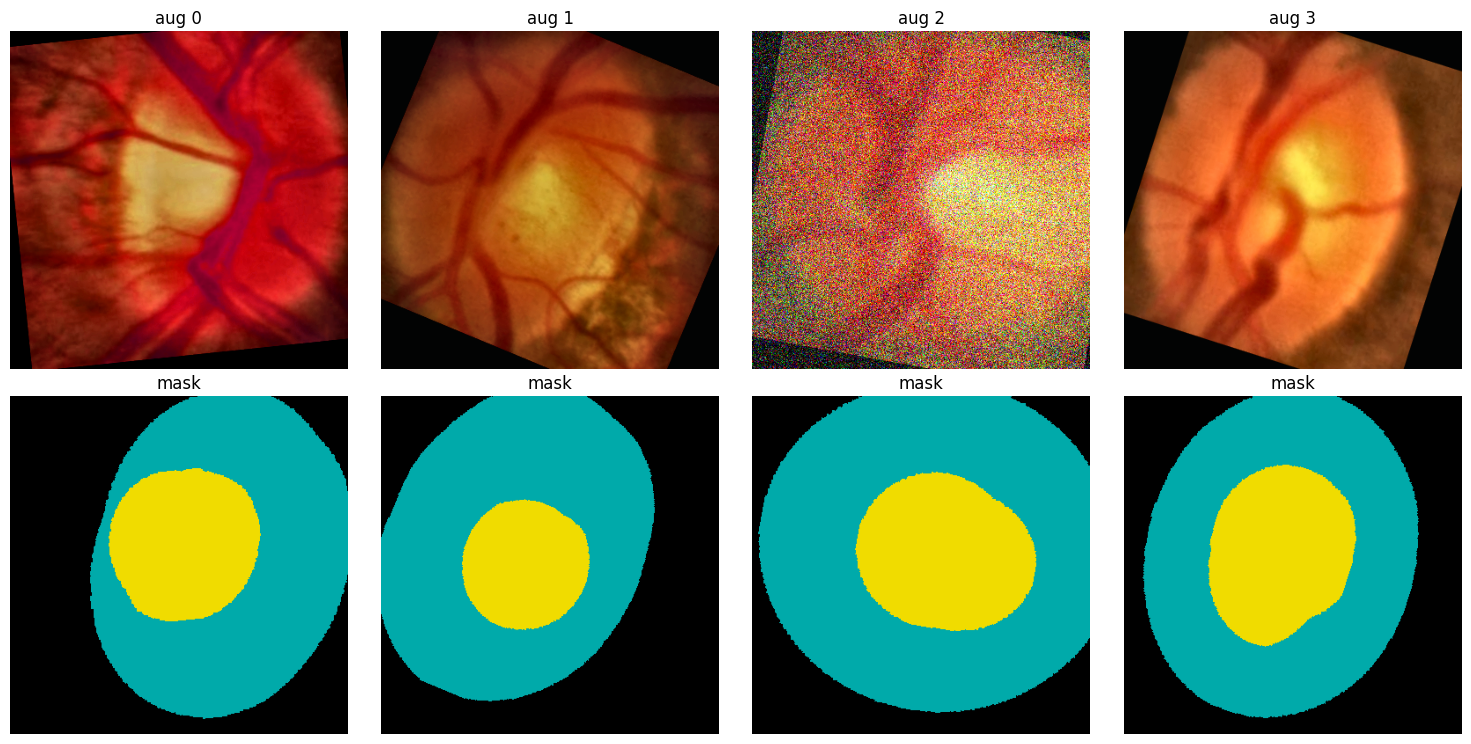

In [ ]:
# ================= CELL 7 — DataLoaders + sanity + augmented samples =================
train_ds=REFUGEDataset(split_pairs["train"],train_tf)
val_ds  =REFUGEDataset(split_pairs["val"],  val_tf)
test_ds =REFUGEDataset(split_pairs["test"], val_tf)
train_loader=DataLoader(train_ds,batch_size=cfg.BATCH_SIZE,shuffle=True,num_workers=cfg.NUM_WORKERS,pin_memory=True,drop_last=True)
val_loader  =DataLoader(val_ds,  batch_size=cfg.BATCH_SIZE,shuffle=False,num_workers=cfg.NUM_WORKERS,pin_memory=True)
test_loader =DataLoader(test_ds, batch_size=cfg.BATCH_SIZE,shuffle=False,num_workers=cfg.NUM_WORKERS,pin_memory=True)
xb,yb=next(iter(train_loader))
print("image",tuple(xb.shape),"| mask",tuple(yb.shape),"| classes",torch.unique(yb).tolist())
def denorm(t):
    img=t.permute(1,2,0).cpu().numpy()*np.array(IMAGENET_STD)+np.array(IMAGENET_MEAN)
    return np.clip(img,0,1)
CMAP=np.array([[0,0,0],[0,170,170],[240,220,0]],np.uint8)
def colorize(m): return CMAP[m]
fig,ax=plt.subplots(2,4,figsize=(15,7.5))
for j in range(4):
    ax[0,j].imshow(denorm(xb[j])); ax[0,j].set_title(f"aug {j}"); ax[0,j].axis("off")
    ax[1,j].imshow(colorize(yb[j].numpy())); ax[1,j].set_title("mask"); ax[1,j].axis("off")
plt.tight_layout(); plt.show()


In [ ]:
# ================= CELL 8 — KAN building blocks (efficient-KAN) =================
class KANLinear(nn.Module):
    def __init__(self,in_features,out_features,grid_size=5,spline_order=3,
                 scale_noise=0.1,scale_base=1.0,scale_spline=1.0,
                 enable_standalone_scale_spline=True,base_activation=nn.SiLU,grid_range=[-1,1]):
        super().__init__()
        self.in_features=in_features; self.out_features=out_features
        self.grid_size=grid_size; self.spline_order=spline_order
        h=(grid_range[1]-grid_range[0])/grid_size
        grid=((torch.arange(-spline_order,grid_size+spline_order+1)*h+grid_range[0])
              .expand(in_features,-1).contiguous())
        self.register_buffer("grid",grid)
        self.base_weight=nn.Parameter(torch.Tensor(out_features,in_features))
        self.spline_weight=nn.Parameter(torch.Tensor(out_features,in_features,grid_size+spline_order))
        self.enable_standalone_scale_spline=enable_standalone_scale_spline
        if enable_standalone_scale_spline:
            self.spline_scaler=nn.Parameter(torch.Tensor(out_features,in_features))
        self.scale_noise=scale_noise; self.scale_base=scale_base; self.scale_spline=scale_spline
        self.base_activation=base_activation(); self.reset_parameters()
    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight,a=math.sqrt(5)*self.scale_base)
        with torch.no_grad():
            noise=((torch.rand(self.grid_size+1,self.in_features,self.out_features)-0.5)
                   *self.scale_noise/self.grid_size)
            self.spline_weight.data.copy_((self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                *self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order],noise))
            if self.enable_standalone_scale_spline:
                nn.init.kaiming_uniform_(self.spline_scaler,a=math.sqrt(5)*self.scale_spline)
    def b_splines(self,x):
        grid=self.grid; x=x.unsqueeze(-1)
        bases=((x>=grid[:,:-1])&(x<grid[:,1:])).to(x.dtype)
        for k in range(1,self.spline_order+1):
            bases=((x-grid[:,:-(k+1)])/(grid[:,k:-1]-grid[:,:-(k+1)])*bases[:,:,:-1]) \
                 +((grid[:,k+1:]-x)/(grid[:,k+1:]-grid[:,1:(-k)])*bases[:,:,1:])
        return bases.contiguous()
    def curve2coeff(self,x,y):
        A=self.b_splines(x).transpose(0,1); B=y.transpose(0,1)
        sol=torch.linalg.lstsq(A,B).solution
        return sol.permute(2,0,1).contiguous()
    @property
    def scaled_spline_weight(self):
        s=self.spline_scaler.unsqueeze(-1) if self.enable_standalone_scale_spline else 1.0
        return self.spline_weight*s
    def forward(self,x):
        orig=x.shape; x=x.reshape(-1,self.in_features)
        base=F.linear(self.base_activation(x),self.base_weight)
        spline=F.linear(self.b_splines(x).view(x.size(0),-1),self.scaled_spline_weight.view(self.out_features,-1))
        return (base+spline).reshape(*orig[:-1],self.out_features)

class DW_bn_relu(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.dwconv=nn.Conv2d(dim,dim,3,1,1,bias=True,groups=dim); self.bn=nn.BatchNorm2d(dim); self.relu=nn.ReLU()
    def forward(self,x,H,W):
        B,N,C=x.shape; x=x.transpose(1,2).view(B,C,H,W); x=self.relu(self.bn(self.dwconv(x)))
        return x.flatten(2).transpose(1,2)

class KANLayer(nn.Module):
    def __init__(self,in_features,hidden_features=None,out_features=None):
        super().__init__()
        hidden_features=hidden_features or in_features; out_features=out_features or in_features
        self.fc1=KANLinear(in_features,hidden_features)
        self.fc2=KANLinear(hidden_features,out_features)
        self.fc3=KANLinear(hidden_features,out_features)
        self.dwconv_1=DW_bn_relu(hidden_features); self.dwconv_2=DW_bn_relu(hidden_features); self.dwconv_3=DW_bn_relu(hidden_features)
    def forward(self,x,H,W):
        B,N,C=x.shape
        x=self.dwconv_1(self.fc1(x.reshape(B*N,C)).reshape(B,N,C),H,W)
        x=self.dwconv_2(self.fc2(x.reshape(B*N,C)).reshape(B,N,C),H,W)
        x=self.dwconv_3(self.fc3(x.reshape(B*N,C)).reshape(B,N,C),H,W)
        return x

class KANBlock(nn.Module):
    def __init__(self,dim,norm_layer=nn.LayerNorm):
        super().__init__(); self.norm2=norm_layer(dim); self.layer=KANLayer(dim,dim)
    def forward(self,x,H,W): return x+self.layer(self.norm2(x),H,W)
print("KAN blocks ready.")


KAN blocks ready.


In [ ]:
# ================= CELL 9 — ResNet34 encoder + KAN bottleneck + U-Net decoder =================
class DecoderBlock(nn.Module):
    """Upsample x2, concat the encoder skip, then DoubleConv."""
    def __init__(self,in_ch,skip_ch,out_ch):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_ch+skip_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(True),
            nn.Conv2d(out_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(True))
    def forward(self,x,skip=None):
        x=F.interpolate(x,scale_factor=2,mode="bilinear",align_corners=False)
        if skip is not None:
            if x.shape[-2:]!=skip.shape[-2:]:
                x=F.interpolate(x,size=skip.shape[-2:],mode="bilinear",align_corners=False)
            x=torch.cat([x,skip],dim=1)
        return self.conv(x)

class ResNet34UKAN(nn.Module):
    def __init__(self,num_classes=3,pretrained=True,kan_depth=1):
        super().__init__()
        try:
            enc=torchvision.models.resnet34(weights="DEFAULT" if pretrained else None)
            print("ResNet34 encoder:", "ImageNet-pretrained" if pretrained else "random init")
        except Exception as e:
            print("[warn] pretrained download failed -> random init:",e)
            enc=torchvision.models.resnet34(weights=None)
        # ---- encoder stages (channels): stem 64(H/2) | layer1 64(H/4) | layer2 128(H/8) | layer3 256(H/16) | layer4 512(H/32)
        self.stem=nn.Sequential(enc.conv1,enc.bn1,enc.relu)
        self.pool=enc.maxpool
        self.layer1=enc.layer1; self.layer2=enc.layer2; self.layer3=enc.layer3; self.layer4=enc.layer4
        # ---- KAN bottleneck on the 512-ch feature map ----
        self.kan_blocks=nn.ModuleList([KANBlock(512) for _ in range(kan_depth)])
        # ---- decoder ----
        self.dec4=DecoderBlock(512,256,256)   # H/32 -> H/16 (+layer3)
        self.dec3=DecoderBlock(256,128,128)   # -> H/8  (+layer2)
        self.dec2=DecoderBlock(128, 64, 64)   # -> H/4  (+layer1)
        self.dec1=DecoderBlock( 64, 64, 32)   # -> H/2  (+stem)
        self.dec0=DecoderBlock( 32,  0, 16)   # -> H
        self.final=nn.Conv2d(16,num_classes,1)
    def forward(self,x):
        x0=self.stem(x)                # 64, H/2
        x1=self.layer1(self.pool(x0))  # 64, H/4
        x2=self.layer2(x1)             # 128, H/8
        x3=self.layer3(x2)             # 256, H/16
        x4=self.layer4(x3)             # 512, H/32
        # KAN bottleneck: tokenize -> KANBlock -> reshape back
        B,C,H,W=x4.shape
        t=x4.flatten(2).transpose(1,2)                 # B, N=H*W, C
        for blk in self.kan_blocks: t=blk(t,H,W)
        x4=t.transpose(1,2).reshape(B,C,H,W)
        d=self.dec4(x4,x3); d=self.dec3(d,x2); d=self.dec2(d,x1); d=self.dec1(d,x0); d=self.dec0(d,None)
        return self.final(d)

model=ResNet34UKAN(cfg.NUM_CLASSES,cfg.PRETRAINED,cfg.KAN_DEPTH).to(DEVICE)
with torch.no_grad():
    o=model(torch.randn(2,3,cfg.IMG_SIZE,cfg.IMG_SIZE,device=DEVICE))
print("output shape:",tuple(o.shape),"| params:",f"{sum(p.numel() for p in model.parameters()):,}")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 221MB/s]


ResNet34 encoder: ImageNet-pretrained
output shape: (2, 3, 384, 384) | params: 32,321,043


In [ ]:
# ================= CELL 10 — Loss = CE + Dice (+ optional Focal-Tversky) =================
class DiceLoss(nn.Module):
    def __init__(self,n,smooth=1e-6): super().__init__(); self.n=n; self.s=smooth
    def forward(self,logits,t):
        p=F.softmax(logits,1); t1=F.one_hot(t,self.n).permute(0,3,1,2).float(); d=(0,2,3)
        inter=(p*t1).sum(d); card=p.sum(d)+t1.sum(d)
        return 1-((2*inter+self.s)/(card+self.s)).mean()
class FocalTverskyLoss(nn.Module):
    def __init__(self,n,a=0.4,b=0.6,g=0.75,smooth=1e-6): super().__init__(); self.n=n; self.a=a; self.b=b; self.g=g; self.s=smooth
    def forward(self,logits,t):
        p=F.softmax(logits,1); t1=F.one_hot(t,self.n).permute(0,3,1,2).float(); d=(0,2,3)
        tp=(p*t1).sum(d); fp=(p*(1-t1)).sum(d); fn=((1-p)*t1).sum(d)
        tv=(tp+self.s)/(tp+self.a*fp+self.b*fn+self.s)
        return ((1-tv)**self.g).mean()
class CombinedLoss(nn.Module):
    def __init__(self,cfg,device):
        super().__init__()
        w=torch.tensor(cfg.CLASS_WEIGHTS,dtype=torch.float32,device=device)
        self.ce=nn.CrossEntropyLoss(weight=w); self.dice=DiceLoss(cfg.NUM_CLASSES)
        self.ft=FocalTverskyLoss(cfg.NUM_CLASSES,cfg.TVERSKY_ALPHA,cfg.TVERSKY_BETA,cfg.TVERSKY_GAMMA)
        self.wce,self.wd,self.wft=cfg.W_CE,cfg.W_DICE,cfg.W_FT
    def forward(self,logits,t):
        loss=self.wce*self.ce(logits,t)+self.wd*self.dice(logits,t)
        if self.wft>0: loss=loss+self.wft*self.ft(logits,t)
        return loss
criterion=CombinedLoss(cfg,DEVICE)
print(f"Loss: {cfg.W_CE}*CE + {cfg.W_DICE}*Dice + {cfg.W_FT}*FT | class weights {cfg.CLASS_WEIGHTS}")


Loss: 0.5*CE + 0.5*Dice + 0.0*FT | class weights [1.0, 1.0, 1.0]


In [ ]:
# ================= CELL 11 — Metrics =================
@torch.no_grad()
def compute_all_metrics(logits,targets,num_classes=3,smooth=1e-6):
    preds=torch.argmax(logits,1); out={k:[] for k in ["dice","iou","precision","recall","f1"]}
    for c in range(num_classes):
        pc,tc=(preds==c),(targets==c)
        tp=(pc&tc).sum().float(); fp=(pc&~tc).sum().float(); fn=(~pc&tc).sum().float()
        pr=(tp+smooth)/(tp+fp+smooth); rc=(tp+smooth)/(tp+fn+smooth)
        out["dice"].append(((2*tp+smooth)/(2*tp+fp+fn+smooth)).item())
        out["iou"].append(((tp+smooth)/(tp+fp+fn+smooth)).item())
        out["precision"].append(pr.item()); out["recall"].append(rc.item())
        out["f1"].append(((2*pr*rc)/(pr+rc+smooth)).item())
    out["accuracy"]=(preds==targets).float().mean().item()
    return out
def hd95_binary(pred_bin,gt_bin):
    from scipy.ndimage import distance_transform_edt as edt
    pred_bin=pred_bin.astype(bool); gt_bin=gt_bin.astype(bool)
    if pred_bin.sum()==0 or gt_bin.sum()==0: return np.nan
    dt_gt=edt(~gt_bin); dt_pred=edt(~pred_bin)
    pe=pred_bin^ndimage.binary_erosion(pred_bin); ge=gt_bin^ndimage.binary_erosion(gt_bin)
    d1=dt_gt[pe]; d2=dt_pred[ge]
    d=np.concatenate([d1,d2]) if (d1.size and d2.size) else (d1 if d1.size else d2)
    return float(np.percentile(d,95)) if d.size else np.nan
print("metrics ready.")


metrics ready.


In [ ]:
# ================= CELL 12 — TWO-LR optimizer + train/eval loops =================
# KAN spline layers (fc1/fc2/fc3 inside kan_blocks) train 100x faster than the conv encoder/decoder.
kan_params, base_params = [], []
for name,p in model.named_parameters():
    if not p.requires_grad: continue
    if ("kan_blocks" in name) and ("fc" in name):   # only the B-spline linear layers
        kan_params.append(p)
    else:
        base_params.append(p)
optimizer=torch.optim.Adam([
    {"params":base_params,"lr":cfg.BASE_LR,"weight_decay":cfg.WEIGHT_DECAY},   # conv encoder + decoder
    {"params":kan_params, "lr":cfg.KAN_LR, "weight_decay":cfg.KAN_WEIGHT_DECAY},# KAN splines
])
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=cfg.EPOCHS,eta_min=cfg.MIN_LR)
scaler=GradScaler(enabled=cfg.USE_AMP)
print(f"conv group: {len(base_params)} tensors @ lr={cfg.BASE_LR} | KAN group: {len(kan_params)} tensors @ lr={cfg.KAN_LR}")

def train_one_epoch():
    model.train(); running=0.0; optimizer.zero_grad(set_to_none=True)
    for i,(imgs,masks) in enumerate(train_loader):
        imgs,masks=imgs.to(DEVICE,non_blocking=True),masks.to(DEVICE,non_blocking=True)
        with autocast(enabled=cfg.USE_AMP):
            loss=criterion(model(imgs),masks)/cfg.ACCUM_STEPS
        scaler.scale(loss).backward()
        if (i+1)%cfg.ACCUM_STEPS==0:
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        running+=loss.item()*cfg.ACCUM_STEPS
    return running/len(train_loader)

@torch.no_grad()
def evaluate(loader):
    model.eval(); agg={k:np.zeros(cfg.NUM_CLASSES) for k in ["dice","iou","precision","recall","f1"]}
    acc=lo=n=0
    for imgs,masks in loader:
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        with autocast(enabled=cfg.USE_AMP):
            logits=model(imgs); loss=criterion(logits,masks)
        m=compute_all_metrics(logits.float(),masks,cfg.NUM_CLASSES)
        for k in agg: agg[k]+=np.array(m[k])
        acc+=m["accuracy"]; lo+=loss.item(); n+=1
    for k in agg: agg[k]/=n
    agg["accuracy"]=acc/n; agg["loss"]=lo/n; agg["mean_dc"]=(agg["dice"][1]+agg["dice"][2])/2
    return agg


conv group: 164 tensors @ lr=0.0001 | KAN group: 9 tensors @ lr=0.01


In [ ]:
# ================= CELL 13 — Training loop (early stop on val mean Dice(D+C)) =================
history={k:[] for k in ["train_loss","val_loss","val_acc","dice","iou","precision","recall","f1","mean_dc"]}
best_dc,best_epoch,patience=-1.0,-1,0; t0=time.time()
for epoch in range(1,cfg.EPOCHS+1):
    tr=train_one_epoch(); scheduler.step(); v=evaluate(val_loader)
    history["train_loss"].append(tr); history["val_loss"].append(v["loss"]); history["val_acc"].append(v["accuracy"])
    for k in ["dice","iou","precision","recall","f1"]: history[k].append(v[k])
    history["mean_dc"].append(v["mean_dc"])
    flag=""
    if v["mean_dc"]>best_dc:
        best_dc,best_epoch,patience=v["mean_dc"],epoch,0
        torch.save({"model":model.state_dict(),"epoch":epoch,"val_mean_dc":float(best_dc)},cfg.CKPT_PATH)
        flag=" -> NEW BEST (saved)"
    else: patience+=1
    print(f"Epoch {epoch:3d}/{cfg.EPOCHS} | train {tr:.4f} | val {v['loss']:.4f} | "
          f"Dice[BG {v['dice'][0]:.3f} Disc {v['dice'][1]:.3f} Cup {v['dice'][2]:.3f}] | MeanDC {v['mean_dc']:.4f}{flag}")
    if patience>=cfg.PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}."); break
print(f"\nDone in {(time.time()-t0)/60:.1f} min | Best val Mean Dice(D+C) = {best_dc:.4f} @ epoch {best_epoch}")


Epoch   1/120 | train 0.7595 | val 0.6977 | Dice[BG 0.824 Disc 0.761 Cup 0.624] | MeanDC 0.6926 -> NEW BEST (saved)
Epoch   2/120 | train 0.6222 | val 0.6231 | Dice[BG 0.876 Disc 0.829 Cup 0.685] | MeanDC 0.7571 -> NEW BEST (saved)
Epoch   3/120 | train 0.5830 | val 0.6281 | Dice[BG 0.869 Disc 0.788 Cup 0.644] | MeanDC 0.7159
Epoch   4/120 | train 0.5585 | val 0.6081 | Dice[BG 0.891 Disc 0.816 Cup 0.652] | MeanDC 0.7339
Epoch   5/120 | train 0.5425 | val 0.5749 | Dice[BG 0.904 Disc 0.841 Cup 0.686] | MeanDC 0.7630 -> NEW BEST (saved)
Epoch   6/120 | train 0.5283 | val 0.5762 | Dice[BG 0.912 Disc 0.811 Cup 0.659] | MeanDC 0.7349
Epoch   7/120 | train 0.5141 | val 0.5804 | Dice[BG 0.913 Disc 0.778 Cup 0.640] | MeanDC 0.7091
Epoch   8/120 | train 0.4998 | val 0.5349 | Dice[BG 0.890 Disc 0.865 Cup 0.722] | MeanDC 0.7934 -> NEW BEST (saved)
Epoch   9/120 | train 0.4893 | val 0.5297 | Dice[BG 0.912 Disc 0.839 Cup 0.705] | MeanDC 0.7721
Epoch  10/120 | train 0.4754 | val 0.5194 | Dice[BG 0.91

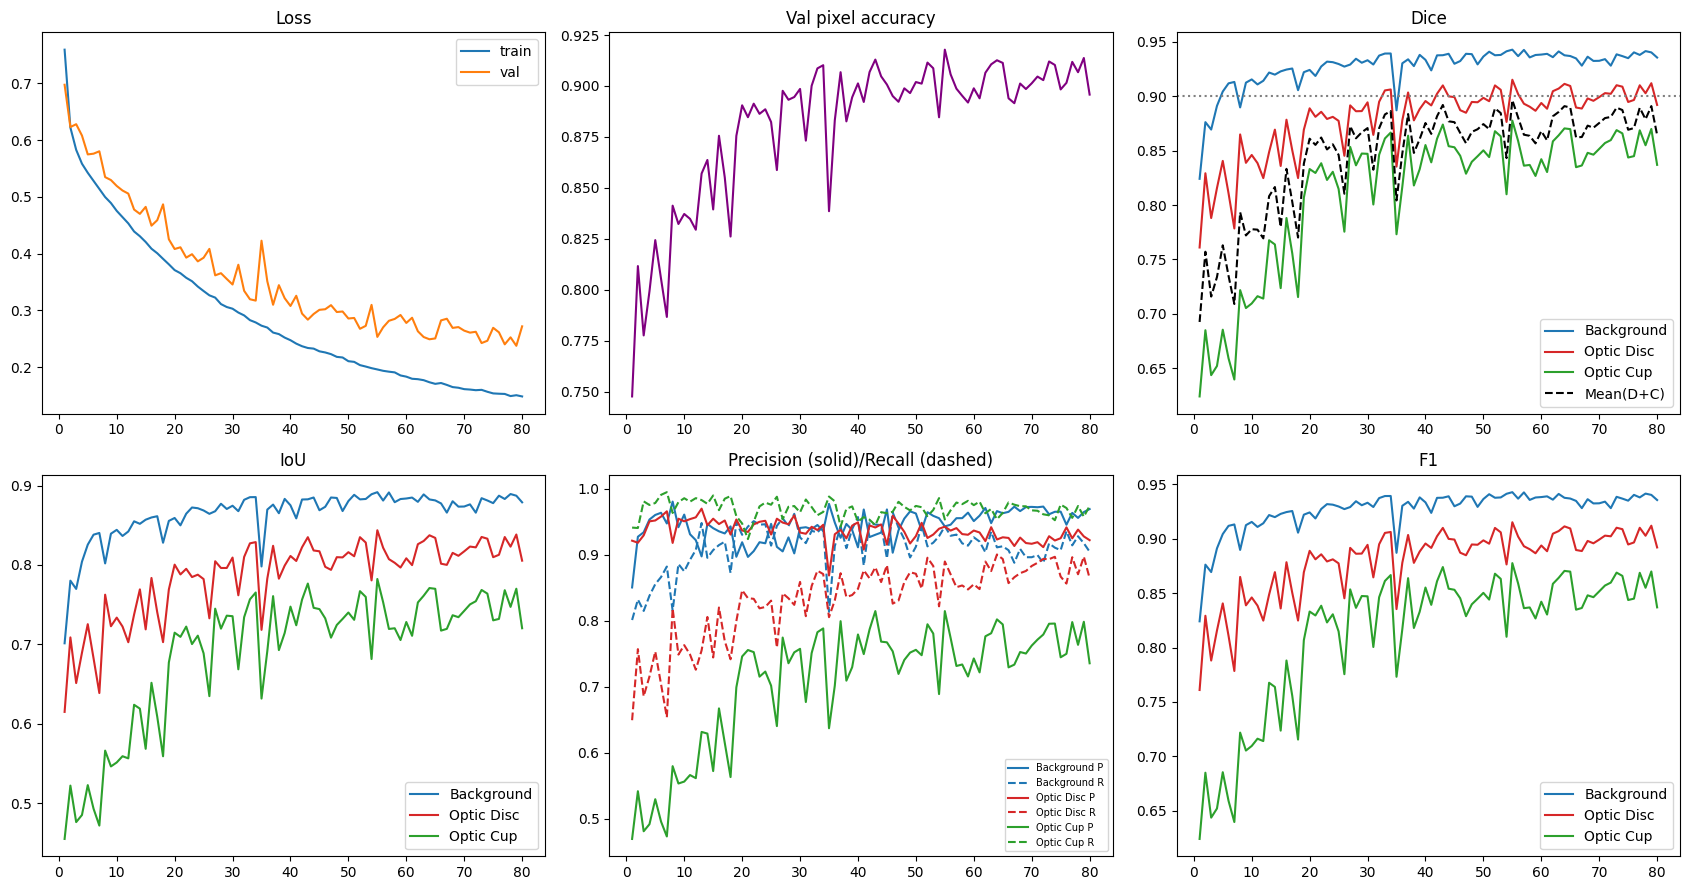

In [ ]:
# ================= CELL 14 — Training curves =================
ep=range(1,len(history["train_loss"])+1)
dice=np.array(history["dice"]); iou=np.array(history["iou"])
prec=np.array(history["precision"]); rec=np.array(history["recall"]); f1=np.array(history["f1"])
names=["Background","Optic Disc","Optic Cup"]; cols=["#1f77b4","#d62728","#2ca02c"]
fig,ax=plt.subplots(2,3,figsize=(17,9))
ax[0,0].plot(ep,history["train_loss"],label="train"); ax[0,0].plot(ep,history["val_loss"],label="val"); ax[0,0].set_title("Loss"); ax[0,0].legend()
ax[0,1].plot(ep,history["val_acc"],color="purple"); ax[0,1].set_title("Val pixel accuracy")
for c in range(3): ax[0,2].plot(ep,dice[:,c],label=names[c],color=cols[c])
ax[0,2].plot(ep,history["mean_dc"],"k--",label="Mean(D+C)"); ax[0,2].axhline(0.90,color="gray",ls=":"); ax[0,2].set_title("Dice"); ax[0,2].legend()
for c in range(3): ax[1,0].plot(ep,iou[:,c],label=names[c],color=cols[c])
ax[1,0].set_title("IoU"); ax[1,0].legend()
for c in range(3):
    ax[1,1].plot(ep,prec[:,c],color=cols[c],label=names[c]+" P"); ax[1,1].plot(ep,rec[:,c],color=cols[c],ls="--",label=names[c]+" R")
ax[1,1].set_title("Precision (solid)/Recall (dashed)"); ax[1,1].legend(fontsize=7)
for c in range(3): ax[1,2].plot(ep,f1[:,c],label=names[c],color=cols[c])
ax[1,2].set_title("F1"); ax[1,2].legend()
plt.tight_layout(); plt.savefig(os.path.join(cfg.OUT_DIR,"training_curves.png"),dpi=120); plt.show()


In [ ]:
# ================= CELL 15 — Post-processing (largest component + cup inside disc) =================
def keep_largest(b):
    if b.sum()==0: return b
    lab,n=ndimage.label(b)
    if n<=1: return b
    sizes=ndimage.sum(np.ones_like(lab),lab,range(1,n+1))
    return lab==(int(np.argmax(sizes))+1)
def postprocess(pred):
    disc=keep_largest(pred==1); cup=keep_largest(pred==2)
    disc_full=ndimage.binary_fill_holes(disc|cup); cup=cup&disc_full
    res=np.zeros_like(pred); res[disc_full]=1; res[cup]=2
    return res.astype(np.uint8)
print("post-processing ready.")


post-processing ready.


In [ ]:
# ================= CELL 16 — Test-Time Augmentation =================
@torch.no_grad()
def predict_probs(imgs,use_tta=True):
    model.eval()
    flips=[lambda t:t,lambda t:torch.flip(t,[3]),lambda t:torch.flip(t,[2]),lambda t:torch.flip(t,[2,3])]
    ops=flips if use_tta else flips[:1]; probs=0
    for f in ops:
        with autocast(enabled=cfg.USE_AMP): logits=model(f(imgs))
        probs=probs+f(F.softmax(logits.float(),1))
    return probs/len(ops)
print("TTA ready (",4 if cfg.USE_TTA else 1,"views ).")


TTA ready ( 4 views ).


In [ ]:
# ================= CELL 17 — Final test evaluation (Raw / +TTA / +TTA+PostProc) =================
ckpt=torch.load(cfg.CKPT_PATH,map_location=DEVICE,weights_only=False)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint epoch {ckpt['epoch']} (val MeanDC={ckpt['val_mean_dc']:.4f})\n")
def evaluate_test(use_tta,use_pp):
    agg={k:np.zeros(cfg.NUM_CLASSES) for k in ["dice","iou","precision","recall","f1"]}; acc=n=0; hdd=[]; hdc=[]
    for imgs,masks in test_loader:
        imgs=imgs.to(DEVICE); preds=predict_probs(imgs,use_tta).argmax(1).cpu().numpy(); mnp=masks.numpy()
        for b in range(preds.shape[0]):
            p=postprocess(preds[b]) if use_pp else preds[b]
            pt=torch.from_numpy(np.asarray(p,dtype=np.int64))[None]; gt=torch.from_numpy(np.asarray(mnp[b],dtype=np.int64))[None]
            m=compute_all_metrics(F.one_hot(pt,cfg.NUM_CLASSES).permute(0,3,1,2).float(),gt,cfg.NUM_CLASSES)
            for k in agg: agg[k]+=np.array(m[k])
            acc+=m["accuracy"]; n+=1; hdd.append(hd95_binary(p==1,mnp[b]==1)); hdc.append(hd95_binary(p==2,mnp[b]==2))
    for k in agg: agg[k]/=n
    return agg,acc/n,(agg["dice"][1]+agg["dice"][2])/2,np.nanmean(hdd),np.nanmean(hdc)
settings=[("Raw",False,False)]
if cfg.USE_TTA: settings.append(("+TTA",True,False))
if cfg.USE_TTA and cfg.USE_POSTPROC: settings.append(("+TTA +PostProc",True,True))
elif cfg.USE_POSTPROC: settings.append(("+PostProc",False,True))
print(f"{'Setting':16s} | {'Disc':>6s} {'Cup':>6s} {'Mean(D+C)':>10s} | {'Acc':>6s} | {'HD95 disc':>9s} {'HD95 cup':>8s}")
print("-"*80); results={}
for nm,tta,pp in settings:
    agg,acc,mdc,hdd,hdc=evaluate_test(tta,pp); results[nm]=(agg,acc,mdc,hdd,hdc)
    print(f"{nm:16s} | {agg['dice'][1]:6.4f} {agg['dice'][2]:6.4f} {mdc:10.4f} | {acc:6.4f} | {hdd:9.2f} {hdc:8.2f}")
bn=settings[-1][0]; agg,acc,mdc,hdd,hdc=results[bn]
print("\n=== Full per-class metrics ("+bn+") ===")
print(f"{'Class':12s} {'Dice':>7s} {'IoU':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s}")
for c,nm in enumerate(["Background","Optic Disc","Optic Cup"]):
    print(f"{nm:12s} {agg['dice'][c]:7.4f} {agg['iou'][c]:7.4f} {agg['precision'][c]:7.4f} {agg['recall'][c]:7.4f} {agg['f1'][c]:7.4f}")
print(f"{'Mean(D+C)':12s} {mdc:7.4f} {(agg['iou'][1]+agg['iou'][2])/2:7.4f}")
print(f"\nTest pixel accuracy: {acc:.4f}")
print("TARGET 0.90 "+("REACHED ✅" if mdc>=0.90 else f"-> {0.90-mdc:+.4f} to go"))
import csv
with open(os.path.join(cfg.OUT_DIR,"test_metrics.csv"),"w",newline="") as f:
    w=csv.writer(f); w.writerow(["setting","disc_dice","cup_dice","mean_dc","accuracy","hd95_disc","hd95_cup"])
    for nm,(a,ac,md,hd,hc) in results.items(): w.writerow([nm,a['dice'][1],a['dice'][2],md,ac,hd,hc])
print("Saved:",os.path.join(cfg.OUT_DIR,"test_metrics.csv"))


Loaded best checkpoint epoch 55 (val MeanDC=0.8963)

Setting          |   Disc    Cup  Mean(D+C) |    Acc | HD95 disc HD95 cup
--------------------------------------------------------------------------------
Raw              | 0.8962 0.8479     0.8721 | 0.9056 |     18.73    25.64
+TTA             | 0.8895 0.8360     0.8627 | 0.9006 |     20.08    27.83
+TTA +PostProc   | 0.8898 0.8362     0.8630 | 0.9009 |     20.75    27.20

=== Full per-class metrics (+TTA +PostProc) ===
Class           Dice     IoU    Prec  Recall      F1
Background    0.9396  0.8873  0.9632  0.9197  0.9396
Optic Disc    0.8898  0.8059  0.9258  0.8608  0.8898
Optic Cup     0.8362  0.7257  0.7451  0.9732  0.8362
Mean(D+C)     0.8630  0.7658

Test pixel accuracy: 0.9009
TARGET 0.90 -> +0.0370 to go
Saved: /content/outputs/test_metrics.csv


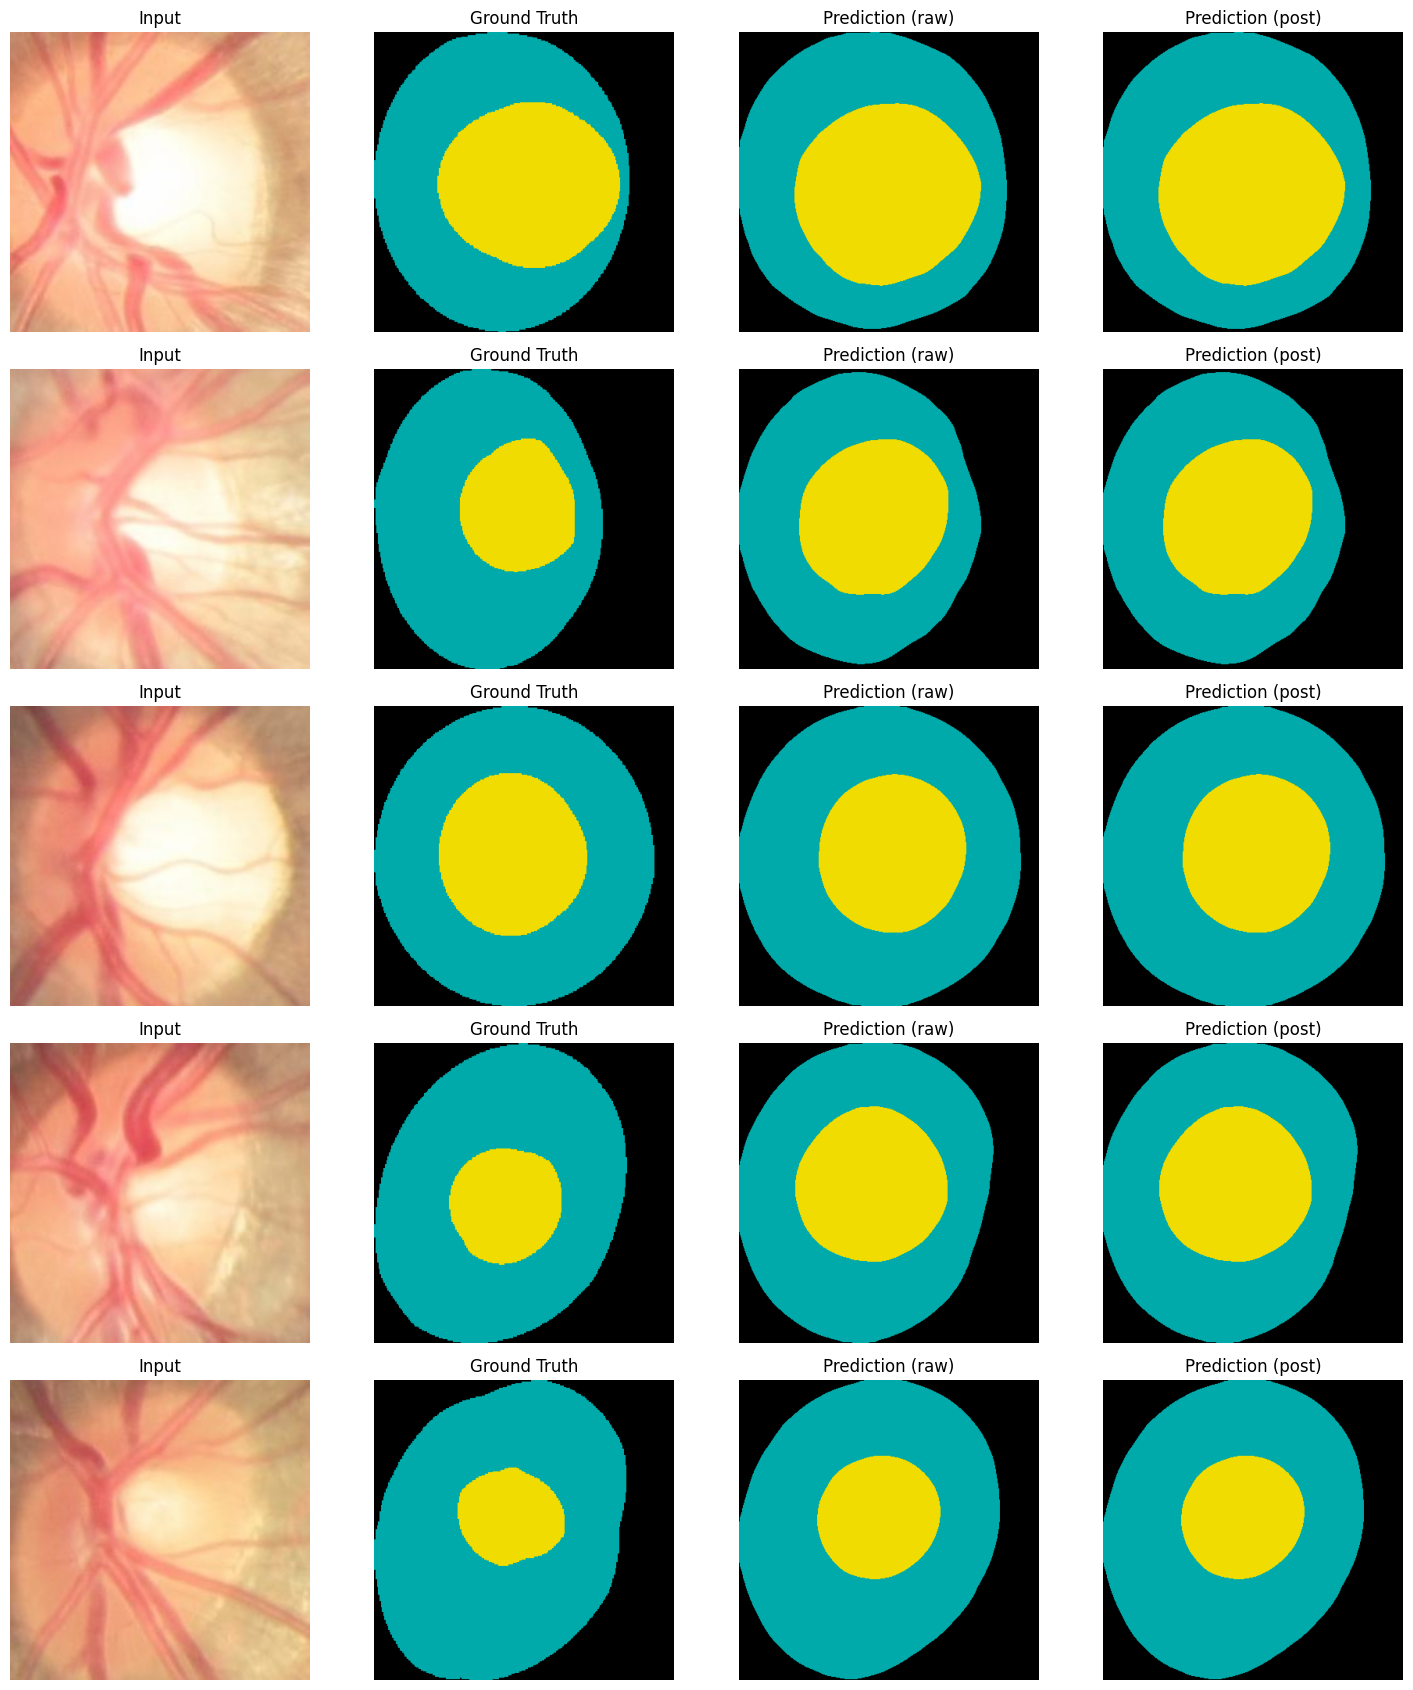

teal=disc, yellow=cup


In [ ]:
# ================= CELL 18 — Qualitative predictions =================
model.eval(); n_show=5; shown=0
fig,ax=plt.subplots(n_show,4,figsize=(15,3.4*n_show))
for imgs,masks in test_loader:
    preds=predict_probs(imgs.to(DEVICE),cfg.USE_TTA).argmax(1).cpu().numpy()
    for b in range(imgs.shape[0]):
        if shown>=n_show: break
        raw=preds[b]; pp=postprocess(raw)
        ax[shown,0].imshow(denorm(imgs[b])); ax[shown,0].set_title("Input"); ax[shown,0].axis("off")
        ax[shown,1].imshow(colorize(masks[b].numpy())); ax[shown,1].set_title("Ground Truth"); ax[shown,1].axis("off")
        ax[shown,2].imshow(colorize(raw)); ax[shown,2].set_title("Prediction (raw)"); ax[shown,2].axis("off")
        ax[shown,3].imshow(colorize(pp)); ax[shown,3].set_title("Prediction (post)"); ax[shown,3].axis("off")
        shown+=1
    if shown>=n_show: break
plt.tight_layout(); plt.savefig(os.path.join(cfg.OUT_DIR,"qualitative.png"),dpi=120); plt.show()
print("teal=disc, yellow=cup")


In [ ]:
# ================= CELL 19 — Run summary =================
print("="*64); print(" ResNet34-U-KAN — REFUGE 3-class — RUN SUMMARY"); print("="*64)
print(f" Encoder             : ResNet34 ({'pretrained' if cfg.PRETRAINED else 'scratch'}) + KAN bottleneck x{cfg.KAN_DEPTH}")
print(f" Image size / params : {cfg.IMG_SIZE} | {sum(p.numel() for p in model.parameters()):,}")
print(f" LRs                 : conv={cfg.BASE_LR}  KAN={cfg.KAN_LR}")
print(f" Best val Mean(D+C)  : {best_dc:.4f} @ epoch {best_epoch}")
bn=settings[-1][0]; a,ac,md,hd,hc=results[bn]
print(f" Test  Mean(D+C)     : {md:.4f} [{bn}] (Disc {a['dice'][1]:.4f}, Cup {a['dice'][2]:.4f})")
print(f" Test accuracy       : {ac:.4f}")
print(f" 0.90 target         : {'REACHED ✅' if md>=0.90 else f'{0.90-md:+.4f} to go'}")
print("="*64)


 ResNet34-U-KAN — REFUGE 3-class — RUN SUMMARY
 Encoder             : ResNet34 (pretrained) + KAN bottleneck x1
 Image size / params : 384 | 32,321,043
 LRs                 : conv=0.0001  KAN=0.01
 Best val Mean(D+C)  : 0.8963 @ epoch 55
 Test  Mean(D+C)     : 0.8630 [+TTA +PostProc] (Disc 0.8898, Cup 0.8362)
 Test accuracy       : 0.9009
 0.90 target         : +0.0370 to go
